### Oto kroki dla ćwiczenia **Reinforcement Learning**:

## 🏁 1. Import bibliotek

Importujemy potrzebne narzędzia:
- numpy do obliczeń
- matplotlib do prostego wykresu

### 📖 Wytłumaczenie:
W RL agent podejmuje decyzje w środowisku i uczy się na podstawie nagród.  
Nasz agent będzie próbował nauczyć się osiągnąć cel w prostym świecie!

### 💡 Ćwiczenie:
Dodaj `import random` i wylosuj liczbę: `random.randint(1, 5)`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 🎯 2. Definicja prostego środowiska

Tworzymy bardzo uproszczony świat: agent zaczyna na pozycji 0 i ma za zadanie dotrzeć do pozycji 10.

### 📖 Wytłumaczenie:
Świat = jedna linia liczb od 0 do 10.  
Agent w każdym kroku może:
- przesunąć się o +1 (do przodu)
- lub o -1 (wstecz, ale tego nie chce!)

### 💡 Ćwiczenie:
Zmodyfikuj `goal_position`, aby agent musiał dotrzeć np. do 5 lub 15.

In [ ]:
goal_position = 10
state = 0


## 🧠 Dlaczego tu nie ma klasycznego „modelu”?

W klasycznym uczeniu maszynowym (np. supervised learning) uczymy model na gotowym zbiorze danych. Ale w uczeniu przez wzmacnianie (reinforcement learning):

- **Nie mamy danych wejściowych i wyjściowych z góry.**
- **Agent sam uczy się przez próby, błędy i nagrody.**
- Uczy się **strategii działania**, a nie dopasowania do danych.

W tym ćwiczeniu nasz agent nie korzysta z gotowego modelu ML (np. `LogisticRegression`), tylko **buduje tablicę Q-wartości** – to jego wewnętrzny „model” świata.

Nie widzimy więc `fit()` ani `predict()` – zamiast tego uczymy się poprzez powtarzalne doświadczenie.


## 🧠 3. Definicja strategii (polityki)

Agent podejmuje decyzję losowo: z 90% szans idzie do przodu, z 10% szans cofa się.

### 📖 Wytłumaczenie:
Na razie agent nie myśli — działa według bardzo prostej zasady (prawie zawsze do przodu).

### 💡 Ćwiczenie:
Zmodyfikuj prawdopodobieństwo — co się stanie, gdy będzie bardziej losowy?

In [ ]:
def policy(state):
    if np.random.rand() < 0.8:
        return 1  # krok do przodu
    else:
        return -1  # krok wstecz

## 🏃 4. Symulacja ruchu agenta

Tworzymy pętlę, w której agent rusza się krok po kroku.

### 📖 Wytłumaczenie:
Agent będzie próbował dotrzeć do celu — zapisujemy wszystkie kroki do późniejszej analizy.

### 💡 Ćwiczenie:
Dodaj limit maksymalnej liczby kroków (np. `if len(path) > 100: break`).

In [ ]:
path = [state]

while state != goal_position:
    action = policy(state)
    state += action
    path.append(state)

## 📈 5. Wizualizacja drogi agenta

Rysujemy, jak agent przesuwał się w stronę celu.

### 📖 Wytłumaczenie:
Widzimy na wykresie, ile kroków zajęło agentowi dojście do celu i czy np. cofał się po drodze.

### 💡 Ćwiczenie:
Zmodyfikuj kolory wykresu (`color='red'`, `color='green'`) albo dodaj tytuł własnymi słowami.

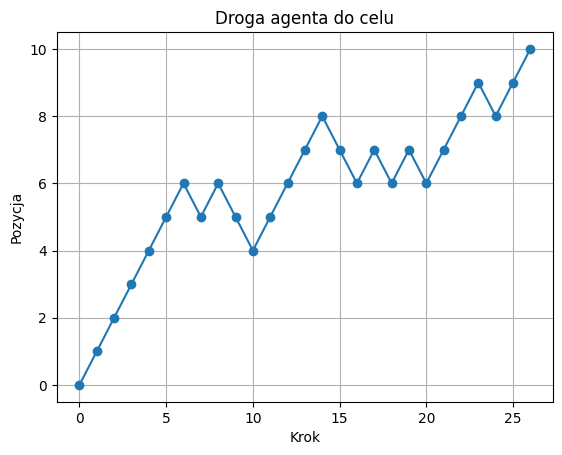

In [ ]:
plt.plot(path, marker='o')
plt.title("Droga agenta do celu")
plt.xlabel("Krok")
plt.ylabel("Pozycja")
plt.grid()
plt.show()

## 🧠 Alternatywna wersja z klasycznym modelem ML (siecią neuronową)

W poprzednich przykładach mogliśmy sobie wyobrazić, że agent zapamiętuje, jak dobre są poszczególne decyzje (akcje) w konkretnych sytuacjach (stanach) — np. w formie prostego słownika lub tablicy:  
**Q[state][action] = wartość**.

Ale gdy stanów i akcji robi się dużo — albo mają formę ciągłych liczb (`x`, `y`, itd.) — taka tablica przestaje być praktyczna.

W tej wersji zamiast zapamiętywać wszystkie możliwe przypadki, agent będzie używał **modelu predykcyjnego** – tu: prostej **sieci neuronowej** – która nauczy się przybliżać wartość Q dla danego stanu i akcji.

Innymi słowy:  
> Dajemy modelowi `[x, y, akcja]` → on przewiduje, **czy ta decyzja się opłaca**.

To działa jak klasyczny `predict()`, ale zamiast klasy lub liczby, model przewiduje **wartość działania** – czyli oczekiwaną nagrodę.

Takie podejście nazywa się czasem:
**function approximation for Q-values** – bo model przybliża (a nie zapamiętuje) wartość funkcji Q.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# Prosty model Q: wejście = [state, action], wyjście = przewidywana wartość Q
class QNetwork(nn.Module):
    def __init__(self):
        super(QNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(3, 16),  # Wejście: 2 współrzędne stanu + 1 akcja = 3 dane wejściowe
            nn.ReLU(),        # Aktywacja – dodajemy nieliniowość
            nn.Linear(16, 1)  # Wyjście: jedna liczba – przewidywana wartość Q
        )

    def forward(self, x):
        return self.fc(x)

# Inicjalizacja modelu i optymalizatora
q_net = QNetwork()
optimizer = optim.Adam(q_net.parameters(), lr=0.01)
loss_fn = nn.MSELoss()  # Funkcja straty – chcemy przybliżyć wartość Q


In [ ]:
# Symulacja nauki – aktualizujemy model na podstawie doświadczeń
# Założenie: state = [x, y], action = 0/1/2/3

# Przykładowe dane treningowe: (stan, akcja, nagroda)
experiences = [
    ([0, 0], 1, 1.0),  # Dobre działanie – nagroda 1.0
    ([0, 1], 2, 0.0),  # Neutralne działanie – brak nagrody
    ([1, 1], 0, 1.0)   # Dobre działanie – nagroda 1.0
]

for epoch in range(100):  # Uczymy model przez 100 powtórzeń (epok)
    total_loss = 0
    for state, action, reward in experiences:
        sa_input = torch.tensor([*state, action], dtype=torch.float32)  # [x, y, action]
        target = torch.tensor([reward], dtype=torch.float32)            # oczekiwana wartość Q

        pred = q_net(sa_input)              # Model przewiduje wartość Q
        loss = loss_fn(pred, target)        # Liczymy błąd między przewidywaną a faktyczną nagrodą

        optimizer.zero_grad()
        loss.backward()                     # Oblicz gradienty
        optimizer.step()                    # Zaktualizuj wagi modelu

        total_loss += loss.item()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")


Epoch 0, Loss: 1.0436
Epoch 20, Loss: 0.0402
Epoch 40, Loss: 0.0001
Epoch 60, Loss: 0.0000
Epoch 80, Loss: 0.0000


In [ ]:
# Sprawdźmy, co model myśli po treningu
test_inputs = [
    ([0, 0], 1),
    ([0, 1], 2),
    ([1, 1], 0)
]

for state, action in test_inputs:
    input_tensor = torch.tensor([*state, action], dtype=torch.float32)
    prediction = q_net(input_tensor).item()
    print(f"Q({state}, {action}) = {prediction:.2f}")


Q([0, 0], 1) = 1.00
Q([0, 1], 2) = 0.00
Q([1, 1], 0) = 1.00



## 🚧 Utrudnienie drogi agenta – przeszkody i lepsza wizualizacja

Dodajemy kilka przeszkód, których agent ma unikać.  
Zobaczymy, czy uda mu się je ominąć, i pokażemy jego drogę na kolorowym wykresie.


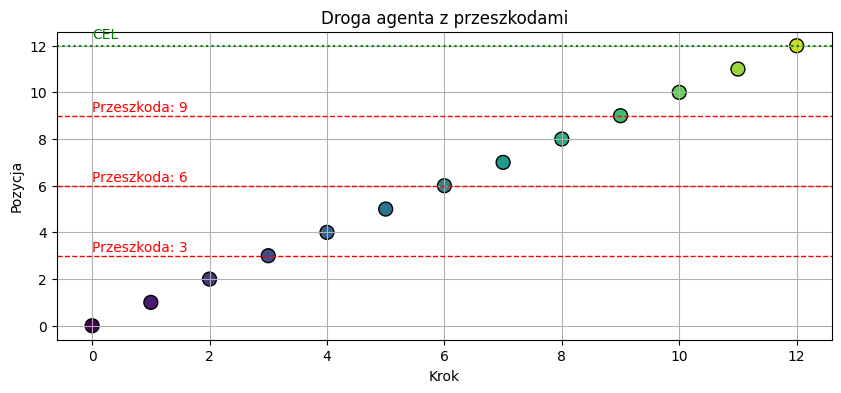

In [ ]:

import matplotlib.pyplot as plt

# Przykładowe przeszkody
obstacles = [3, 6, 9]

# Stan początkowy i cel
goal_position = 12
state = 0
path = [state]

# Strategia jak wcześniej
def policy(state):
    if np.random.rand() < 0.9:
        return 1
    else:
        return -1

# Symulacja ruchu
while state != goal_position:
    action = policy(state)
    state += action
    path.append(state)
    if len(path) > 100:
        print("Za dużo kroków — przerwanie symulacji.")
        break

# Kolorowanie punktów na podstawie kolejności
steps = list(range(len(path)))
colors = [plt.cm.viridis(i / len(path)) for i in steps]

# Rysowanie
plt.figure(figsize=(10, 4))
plt.scatter(steps, path, c=colors, s=100, edgecolors='black')

# Zaznacz przeszkody
for obs in obstacles:
    plt.axhline(y=obs, color='red', linestyle='--', linewidth=1)
    plt.text(0, obs + 0.2, f"Przeszkoda: {obs}", color='red')

# Zaznacz cel
plt.axhline(y=goal_position, color='green', linestyle=':', linewidth=1.5)
plt.text(0, goal_position + 0.3, "CEL", color='green')

plt.title("Droga agenta z przeszkodami")
plt.xlabel("Krok")
plt.ylabel("Pozycja")
plt.grid(True)
plt.show()


In [ ]:
# Parametry środowiska
n_states = 13
actions = [0, 1]  # 0: lewo, 1: prawo
obstacles = [3, 6, 9]
goal = 12

# Parametry Q-learningu
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 0.2    # eksploracja
episodes = 10

# Inicjalizacja Q-tablicy
Q = np.zeros((n_states, len(actions)))

# Definicja funkcji nagrody i przejścia
def step(state, action):
    if action == 0:
        next_state = max(0, state - 1)
    else:
        next_state = min(n_states - 1, state + 1)

    # Kara za przeszkodę
    if next_state in obstacles:
        reward = -10
        next_state = state  # agent się odbija
    elif next_state == goal:
        reward = 10
    else:
        reward = -1  # każdy krok kosztuje

    return next_state, reward

# Trening
for ep in range(episodes):
    state = 0
    done = False
    while not done:
        # Epsilon-greedy policy
        if np.random.rand() < epsilon:
            action = np.random.choice(actions)
        else:
            action = np.argmax(Q[state])

        next_state, reward = step(state, action)

        # Aktualizacja Q
        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

        if next_state == goal:
            done = True

        state = next_state

# Testowanie wyuczonej polityki
state = 0
path = [state]
while state != goal:
    action = np.argmax(Q[state])
    next_state, _ = step(state, action)
    path.append(next_state)
    if len(path) > 100:
        print("Za długo — przerywam.")
        break
    state = next_state

# Wizualizacja
steps = list(range(len(path)))
colors = [plt.cm.plasma(i / len(path)) for i in steps]

plt.figure(figsize=(10, 4))
plt.scatter(steps, path, c=colors, s=100, edgecolors='black')

for obs in obstacles:
    plt.axhline(y=obs, color='red', linestyle='--', linewidth=1)
    plt.text(0, obs + 0.2, f"Przeszkoda: {obs}", color='red')

plt.axhline(y=goal, color='green', linestyle=':', linewidth=1.5)
plt.text(0, goal + 0.3, "CEL", color='green')

plt.title("Agent z Q-learningiem – ścieżka po nauce")
plt.xlabel("Krok")
plt.ylabel("Pozycja")
plt.grid(True)
plt.show()

KeyboardInterrupt: 


## 🌍 Wersja 2D: Agent porusza się na siatce (x, y)

W tej wersji agent może iść w górę, dół, lewo lub prawo.  
Jego celem jest dotarcie do pozycji docelowej, unikając przeszkód.


Dotarł do celu w 20 krokach.


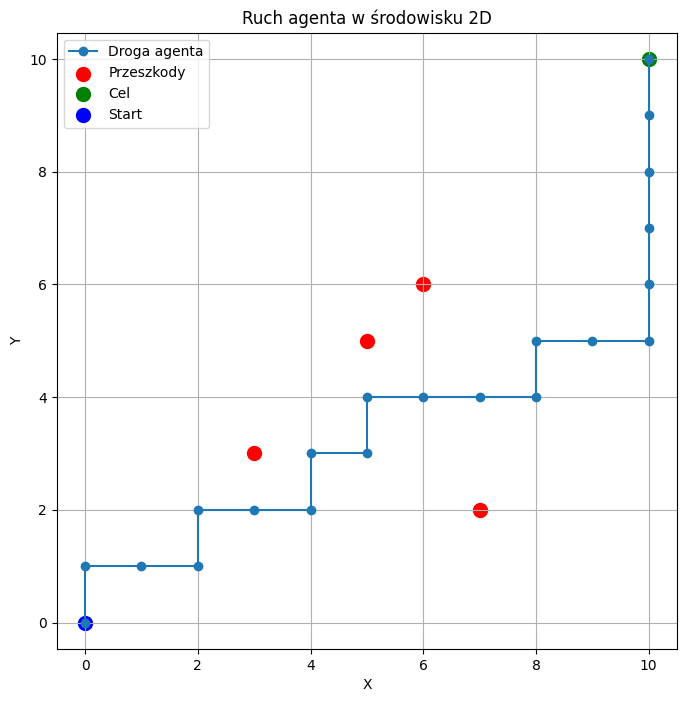

Liczba trafień w przeszkody: 0


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import random

# Parametry środowiska
start = [0, 0]
goal = [10, 10]
obstacles = [[3, 3], [5, 5], [7, 2], [6, 6]]

# Strategia: losowy ruch
def policy(state):
    return random.choice([(1,0), (-1,0), (0,1), (0,-1)])

# Strategia: Idź w stronę celu
def policy_go(state):
    goal_dx = goal[0] - state[0]
    goal_dy = goal[1] - state[1]

    if abs(goal_dx) > abs(goal_dy):
        return (np.sign(goal_dx), 0)
    else:
        return (0, np.sign(goal_dy))

# Strategia: smart
def policy_smart(state):
    directions = [(1,0), (-1,0), (0,1), (0,-1)]
    random.shuffle(directions)  # trochę eksploracji

    # Preferuj kierunek prowadzący bliżej celu, ale sprawdź, czy nie ma przeszkody
    for dx, dy in directions:
        next_state = [state[0] + dx, state[1] + dy]
        dist_now = abs(goal[0] - state[0]) + abs(goal[1] - state[1])
        dist_next = abs(goal[0] - next_state[0]) + abs(goal[1] - next_state[1])
        if dist_next < dist_now and next_state not in obstacles:
            return (dx, dy)

    # Jeśli nie znaleziono nic sensownego — idź losowo (ale nie w przeszkodę)
    for dx, dy in directions:
        next_state = [state[0] + dx, state[1] + dy]
        if next_state not in obstacles:
            return (dx, dy)

    # Ostateczność – zostaje w miejscu
    return (0, 0)

# Symulacja
state = start[:]
path = [state[:]]
hits = 0

for step in range(100):
    action = policy_smart(state) # AKCJA KTÓRĄ PODEJMUJE AGENT
    next_state = [state[0] + action[0], state[1] + action[1]]

    if next_state in obstacles:
        hits += 1
        continue  # nie ruszaj się w przeszkodę

    state = next_state
    path.append(state[:])

    if state == goal:
        print(f"Dotarł do celu w {step+1} krokach.")
        break

# Przygotuj dane do wykresu
x_vals = [p[0] for p in path]
y_vals = [p[1] for p in path]
obs_x = [o[0] for o in obstacles]
obs_y = [o[1] for o in obstacles]

# Rysowanie
plt.figure(figsize=(8, 8))
plt.plot(x_vals, y_vals, marker='o', label='Droga agenta')
plt.scatter(obs_x, obs_y, color='red', label='Przeszkody', s=100)
plt.scatter(*goal, color='green', label='Cel', s=100)
plt.scatter(*start, color='blue', label='Start', s=100)
plt.title("Ruch agenta w środowisku 2D")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

print(f"Liczba trafień w przeszkody: {hits}")
